# ARIMA / SARIMA Time Series Modeling

This notebook continues from the Feature Engineering notebook.

The goal is to build classical time series models to forecast daily `unit_sales` using the prepared feature dataset.

## Step 1 — Import libraries

In [4]:
!pip install scikit-learn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings


from pathlib import Path

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2 — Define paths

The feature dataset was created in the previous notebook and saved in the `outputs` folder because it is generated during feature engineering.

## Step 3 — Load the feature dataset

This dataset contains the cleaned sales series together with calendar, holiday, oil, lag, and rolling features.

In [6]:
from pathlib import Path
import pandas as pd

features_path = Path("../outputs/timeseries_with_features.csv")

print("Path:", features_path.resolve())
print("Exists:", features_path.exists())

df = pd.read_csv(features_path, parse_dates=["date"])

print("Dataset loaded:", df.shape)
df.head()

Path: /home/ana/cosas_eukene/accounts/github/time_series_analysis_ona/outputs/timeseries_with_features.csv
Exists: True
Dataset loaded: (424, 31)


,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier,...,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_lag_7,oil_rolling_7d_mean
0,2013-02-01,401.0,Friday,4,2,2013,0,456.285714,-0.444388,False,...,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.65,95.15,96.378571
1,2013-02-02,775.0,Saturday,5,2,2013,1,467.428571,1.714749,False,...,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,95.15,96.708571
2,2013-02-03,855.0,Sunday,6,2,2013,1,501.571429,2.176596,False,...,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,95.15,97.038571
3,2013-02-04,411.0,Monday,0,2,2013,0,514.857143,-0.386657,False,...,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,97.46,95.95,97.368571
4,2013-02-05,272.0,Tuesday,1,2,2013,0,497.571429,-1.189117,False,...,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.21,97.62,97.405714


In [7]:
df = pd.read_csv(features_path, parse_dates=["date"])

df = df.sort_values("date").reset_index(drop=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

display(df.head())

Dataset loaded successfully.
Shape: (424, 31)
Date range: 2013-02-01 00:00:00 to 2014-03-31 00:00:00


,date,unit_sales,day_of_week,day_number,month,year,is_weekend,rolling_7d,zscore,is_outlier,...,lag_7,lag_14,lag_30,rolling_7d_mean,rolling_14d_mean,rolling_30d_mean,rolling_7d_std,oil_lag_1,oil_lag_7,oil_rolling_7d_mean
0,2013-02-01,401.0,Friday,4,2,2013,0,456.285714,-0.444388,False,...,389.0,60.0,582.0,454.571429,497.071429,520.833333,154.059358,97.65,95.15,96.378571
1,2013-02-02,775.0,Saturday,5,2,2013,1,467.428571,1.714749,False,...,697.0,667.0,310.0,456.285714,521.428571,514.800000,153.272866,97.46,95.15,96.708571
2,2013-02-03,855.0,Sunday,6,2,2013,1,501.571429,2.176596,False,...,616.0,1090.0,338.0,467.428571,529.142857,530.300000,174.986530,97.46,95.15,97.038571
3,2013-02-04,411.0,Monday,0,2,2013,0,514.857143,-0.386657,False,...,318.0,760.0,654.0,501.571429,512.357143,547.533333,224.981375,97.46,95.95,97.368571
4,2013-02-05,272.0,Tuesday,1,2,2013,0,497.571429,-1.189117,False,...,393.0,461.0,979.0,514.857143,487.428571,539.433333,214.852219,96.21,97.62,97.405714


## Step 4 — Prepare the time series for ARIMA/SARIMA

For ARIMA and SARIMA, the target variable should be indexed by date and follow a regular frequency.

Here, the target is daily `unit_sales`.

In [8]:
ts = df[["date", "unit_sales"]].copy()

ts = (
    ts
    .set_index("date")
    .asfreq("D")
)

print("Time series frequency:", ts.index.freq)
print("Missing values:")
print(ts.isna().sum())

display(ts.head())

Time series frequency: <Day>
Missing values:
unit_sales    0
dtype: int64


,unit_sales
date,
2013-02-01,401.0
2013-02-02,775.0
2013-02-03,855.0
2013-02-04,411.0
2013-02-05,272.0


The target variable `unit_sales` was selected and indexed by date.

A daily frequency was enforced using `asfreq("D")`. The validation confirms that the series has a regular daily frequency and contains no missing values, so it is suitable for ARIMA/SARIMA modeling.

## Step 5 — Visualize the sales series

Before modeling, I plot the sales series to inspect the overall behavior, including volatility, possible weekly patterns, and unusual spikes.

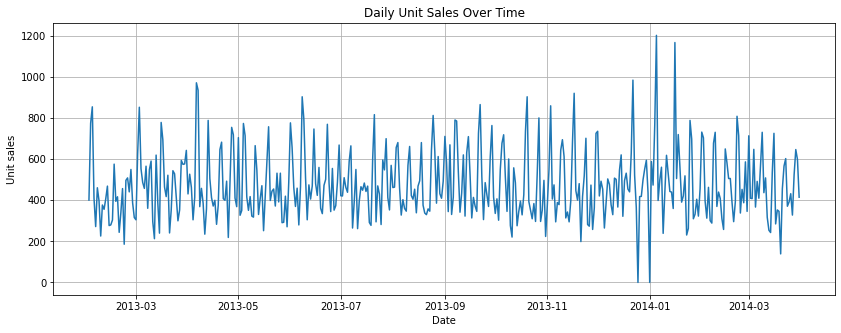

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts["unit_sales"])
plt.title("Daily Unit Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.grid(True)
plt.show()

The time series shows strong day-to-day variability, with frequent fluctuations in sales.

There is no clear long-term upward or downward trend, but recurring patterns suggest possible weekly seasonality. Several sharp spikes and drops are also visible, indicating the presence of outliers or special events affecting sales.

Overall, the series appears noisy, which is typical for daily retail data.

## Step 6 — Decompose the time series

The sales series is decomposed into trend, seasonal, and residual components.

Because this is daily sales data, I use a period of 7 to inspect weekly seasonality.

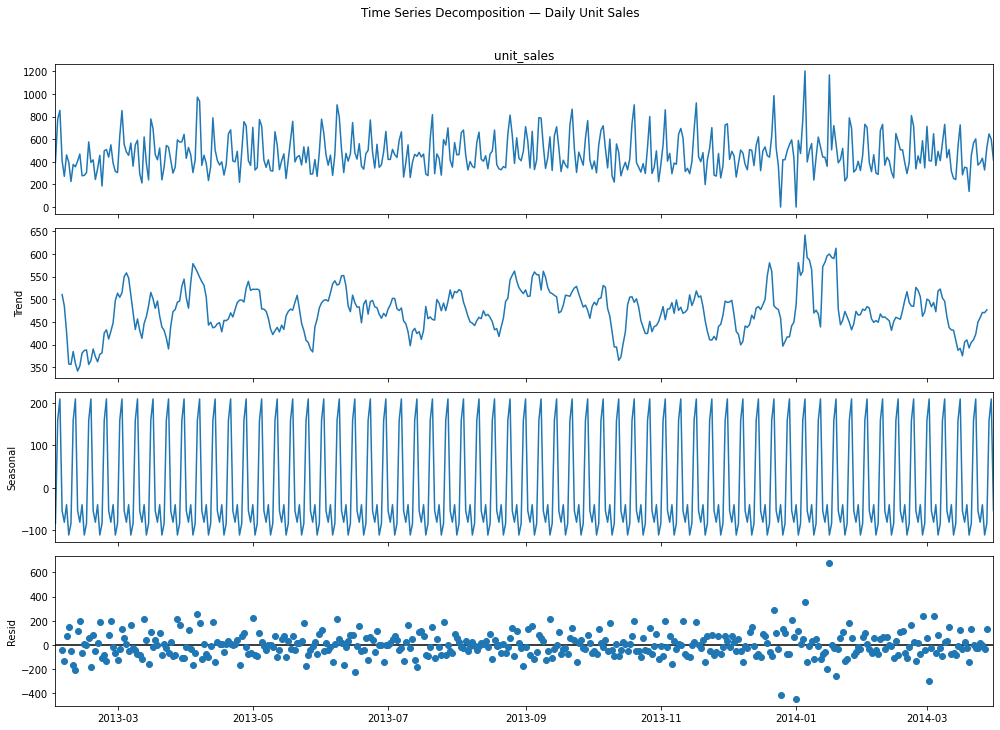

In [10]:
decomposition = seasonal_decompose(
    ts["unit_sales"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle("Time Series Decomposition — Daily Unit Sales", y=1.01)
plt.tight_layout()
plt.show()

The time series was decomposed into trend, seasonal, and residual components using a period of 7 to capture weekly patterns.

The seasonal component shows a strong and consistent weekly pattern, confirming the presence of weekly seasonality in the data. The trend component remains relatively stable over time, with no strong long-term upward or downward movement.

The residuals appear mostly random, although some large spikes are present, indicating occasional outliers or unusual events in the sales data.

## Step 7 — Check stationarity

ARIMA models assume that the series is stationary, meaning that its average and variance are relatively stable over time.

I use the Augmented Dickey-Fuller test to check this statistically.

In [11]:
def check_stationarity(series, name):
    series = series.dropna()
    result = adfuller(series)
    p_value = result[1]

    print(f"ADF Test for: {name}")
    print("p-value:", round(p_value, 4))

    if p_value <= 0.05:
        print("Result: The series appears stationary.")
    else:
        print("Result: The series appears non-stationary and may need differencing.")
    print()

check_stationarity(ts["unit_sales"], "Original unit_sales")

ADF Test for: Original unit_sales
p-value: 0.0
Result: The series appears stationary.



The Augmented Dickey-Fuller test returns a p-value close to 0, indicating that the series is statistically stationary.

This suggests that no regular differencing (d) is required. However, the decomposition analysis revealed a strong weekly seasonal pattern.

Therefore, while the series is stationary in terms of level, seasonal differencing will still be needed to account for the weekly seasonality when building the SARIMA model.

## Step 8 — Create differenced series

I create first differencing and weekly seasonal differencing to compare which version looks more stable.

For daily retail sales, a 7-day seasonal difference is useful because sales often follow weekly patterns.

In [12]:
ts["diff_1"] = ts["unit_sales"].diff()
ts["diff_7"] = ts["unit_sales"].diff(7)
ts["diff_1_7"] = ts["diff_1"].diff(7)

display(ts.head(15))

,unit_sales,diff_1,diff_7,diff_1_7
date,,,,
2013-02-01,401.0,NaN,NaN,NaN
2013-02-02,775.0,374.0,NaN,NaN
2013-02-03,855.0,80.0,NaN,NaN
2013-02-04,411.0,-444.0,NaN,NaN
2013-02-05,272.0,-139.0,NaN,NaN
2013-02-06,461.0,189.0,NaN,NaN
2013-02-07,397.0,-64.0,NaN,NaN
2013-02-08,226.0,-171.0,-175.0,NaN
2013-02-09,377.0,151.0,-398.0,-223.0


Different versions of the series were created using first differencing and weekly seasonal differencing (lag 7).

Since the original series already appears stationary according to the ADF test, first differencing is not strictly required. However, seasonal differencing is important to remove the strong weekly pattern observed in the data.

Therefore, the seasonally differenced series (`diff_7`) is expected to be the most suitable version for model identification.

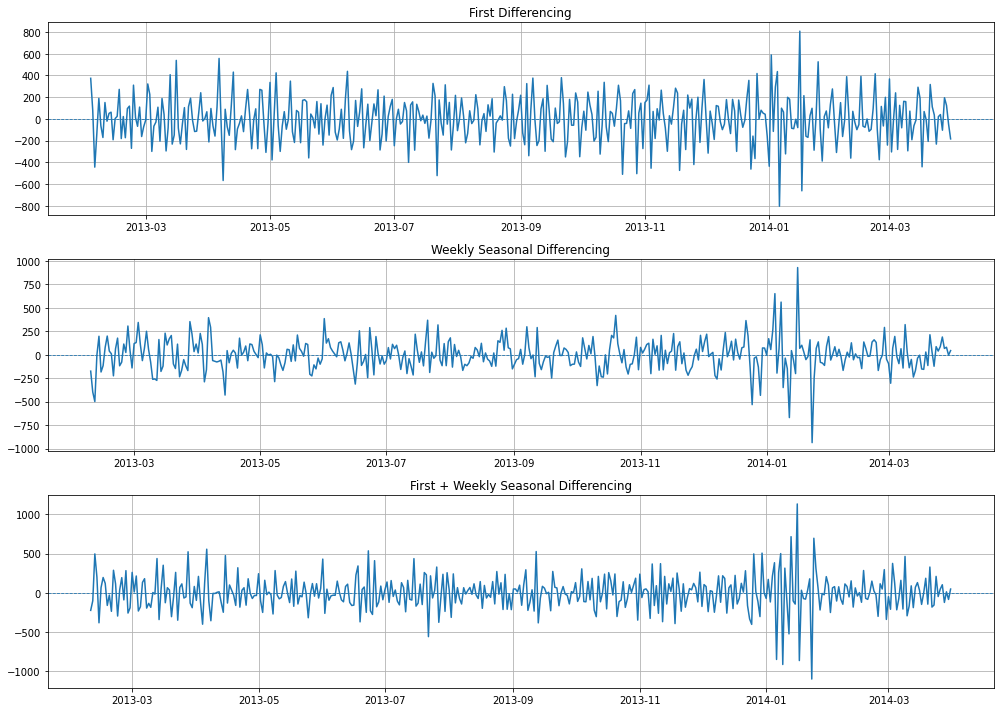

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(ts["diff_1"])
axes[0].set_title("First Differencing")
axes[0].axhline(0, linestyle="--", linewidth=0.8)
axes[0].grid(True)

axes[1].plot(ts["diff_7"])
axes[1].set_title("Weekly Seasonal Differencing")
axes[1].axhline(0, linestyle="--", linewidth=0.8)
axes[1].grid(True)

axes[2].plot(ts["diff_1_7"])
axes[2].set_title("First + Weekly Seasonal Differencing")
axes[2].axhline(0, linestyle="--", linewidth=0.8)
axes[2].grid(True)

plt.tight_layout()
plt.show()

The three differenced versions of the series were compared to assess which transformation produces a more stable signal.

The first differencing reduces some variability but does not remove the weekly pattern. The seasonal differencing (lag 7) produces a series that fluctuates more consistently around zero and removes the weekly structure.

Combining both first and seasonal differencing results in a noisier series, suggesting over-differencing.

Therefore, the seasonally differenced series (lag 7) is selected for model identification.

In [14]:
check_stationarity(ts["diff_1"], "After first differencing")
check_stationarity(ts["diff_7"], "After weekly seasonal differencing")
check_stationarity(ts["diff_1_7"], "After first + weekly seasonal differencing")

ADF Test for: After first differencing
p-value: 0.0
Result: The series appears stationary.

ADF Test for: After weekly seasonal differencing
p-value: 0.0
Result: The series appears stationary.

ADF Test for: After first + weekly seasonal differencing
p-value: 0.0
Result: The series appears stationary.



All differenced versions of the series pass the ADF test, indicating stationarity.

However, stationarity alone is not sufficient to select the best transformation. The seasonal differencing (lag 7) is preferred because it removes the strong weekly pattern observed in the data while maintaining a stable and interpretable structure.

First differencing does not address the seasonal component, and combining both transformations introduces unnecessary noise, suggesting over-differencing.

Therefore, the seasonally differenced series is selected for model identification.

## Step 9 — ACF and PACF plots

ACF and PACF plots help choose ARIMA/SARIMA parameters.

- ACF helps identify possible MA terms (`q`)
- PACF helps identify possible AR terms (`p`)
- Spikes around lag 7 suggest weekly seasonality

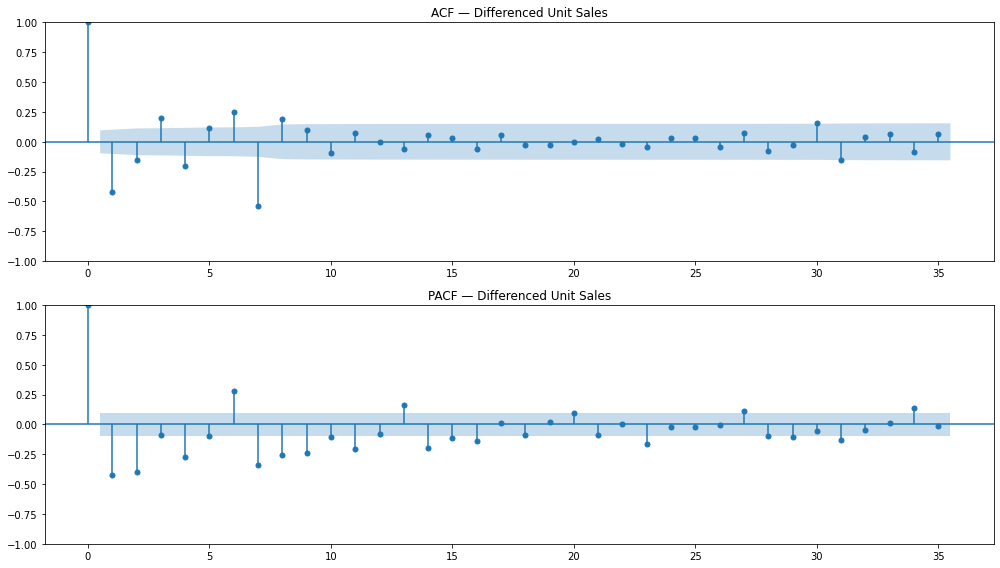

In [16]:
series_for_acf = ts["diff_1_7"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(series_for_acf, lags=35, ax=axes[0])
axes[0].set_title("ACF — Differenced Unit Sales")

plot_pacf(series_for_acf, lags=35, ax=axes[1])
axes[1].set_title("PACF — Differenced Unit Sales")

plt.tight_layout()
plt.show()

The ACF plot shows a significant spike at lag 1 followed by a rapid decay, suggesting the presence of a moving average component (q = 1).

The PACF plot does not show a clear cutoff, indicating that autoregressive terms are likely minimal or unnecessary (p ≈ 0).

A clear spike around lag 7 is also visible, confirming the weekly seasonal structure previously identified.

Based on these observations, a SARIMA(0, 0, 1)(0, 1, 0, 7) model is selected as a starting point.

## Step 10 — Train/test split

For time series, the split must respect chronological order.

I use the older observations for training and the most recent observations for testing.

In [17]:
test_size = int(len(ts) * 0.2)

train = ts.iloc[:-test_size].copy()
test = ts.iloc[-test_size:].copy()

print("Training set:", train.index.min(), "to", train.index.max(), "| rows:", len(train))
print("Test set:", test.index.min(), "to", test.index.max(), "| rows:", len(test))

Training set: 2013-02-01 00:00:00 to 2014-01-06 00:00:00 | rows: 340
Test set: 2014-01-07 00:00:00 to 2014-03-31 00:00:00 | rows: 84


The dataset is split into training and test sets while preserving chronological order.

The first 80% of observations are used for training, and the most recent 20% are reserved for testing. This ensures that the model is evaluated on unseen future data, which better reflects real forecasting conditions.

The test set spans approximately 12 weeks, allowing the model to be evaluated across multiple weekly cycles.

## Step 11 — Fit a SARIMA model

Since the sales data is daily and shows weekly behavior, I use a seasonal period of 7.

This first model is a reasonable starting point, not necessarily the final best model.

In [18]:
# Define SARIMA parameters

# Non-seasonal order: (p, d, q)
# p = 0: no autoregressive term
# d = 0: no regular differencing, because the original series appears stationary
# q = 1: one moving average term suggested by the ACF plot
order = (0, 0, 1)

# Seasonal order: (P, D, Q, s)
# P = 0: no seasonal autoregressive term
# D = 1: one seasonal difference to capture weekly seasonality
# Q = 0: no seasonal moving average term
# s = 7: weekly seasonality in daily data
seasonal_order = (0, 1, 0, 7)

print("Selected SARIMA parameters:")
print("Order:", order)
print("Seasonal order:", seasonal_order)

Selected SARIMA parameters:
Order: (0, 0, 1)
Seasonal order: (0, 1, 0, 7)


In [19]:
# Create the SARIMA model

model = SARIMAX(
    train["unit_sales"],
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

print("Model created successfully.")

Model created successfully.


In [20]:
# Fit the model on the training data

print("Training the model...")

model_fit = model.fit(disp=False)

print("Model training complete.\n")
print(model_fit.summary())

Training the model...
Model training complete.

                                     SARIMAX Results                                      
Dep. Variable:                         unit_sales   No. Observations:                  340
Model:             SARIMAX(0, 0, 1)x(0, 1, [], 7)   Log Likelihood               -2133.715
Date:                            Sat, 02 May 2026   AIC                           4271.430
Time:                                    23:02:46   BIC                           4279.035
Sample:                                02-01-2013   HQIC                          4274.463
                                     - 01-06-2014                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1852      0.051      3.597      0.000       0.084

The SARIMA model was successfully trained on the training data.

The MA(1) coefficient is statistically significant, suggesting that the moving average component helps explain short-term patterns in the sales series. The model also includes weekly seasonal differencing, which is consistent with the weekly seasonality observed earlier.

The Ljung-Box test does not indicate strong remaining autocorrelation at lag 1, which is a positive sign. However, the residuals are not perfectly normally distributed, likely due to spikes and outliers in daily retail sales.

The AIC value will be used later to compare this model with alternative SARIMA configurations.

## Step 12 — Check residuals

Residuals are the errors made by the model on the training data.

A good model should leave residuals that look mostly random, without obvious trend or seasonality.

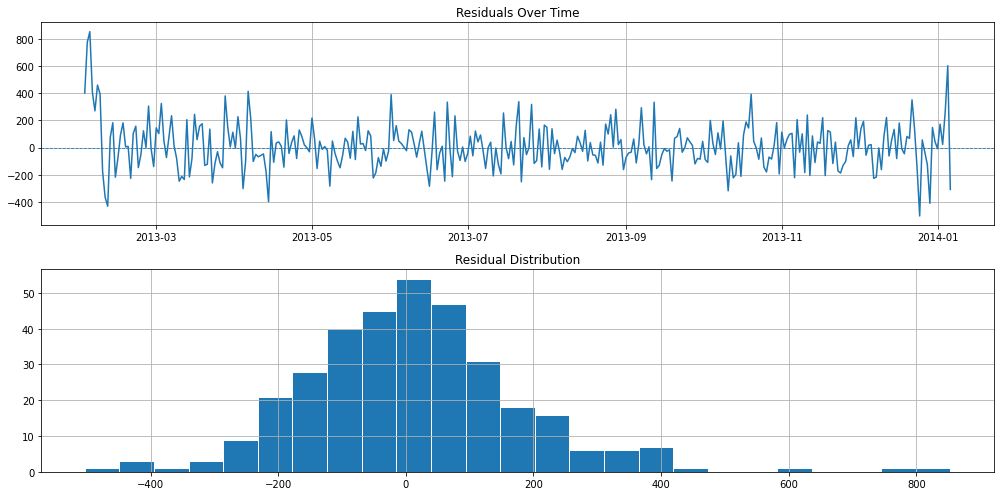

In [21]:
residuals = model_fit.resid

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(residuals)
axes[0].axhline(0, linestyle="--", linewidth=0.8)
axes[0].set_title("Residuals Over Time")
axes[0].grid(True)

axes[1].hist(residuals.dropna(), bins=25, edgecolor="white")
axes[1].set_title("Residual Distribution")
axes[1].grid(True)

plt.tight_layout()
plt.show()

The residuals are analyzed to evaluate the model fit.

The residuals fluctuate around zero without a clear trend, suggesting that the model has captured the main structure of the series.

However, there are several large spikes, indicating that the model does not fully capture extreme values or sudden changes in sales. This is common in daily retail data, where unexpected events or irregular demand can occur.

The distribution of residuals is roughly centered around zero but shows some deviation from a perfect normal distribution, with heavier tails.

Overall, the residual analysis suggests that the model captures the general pattern well, but there is room for improvement, particularly in handling extreme observations.

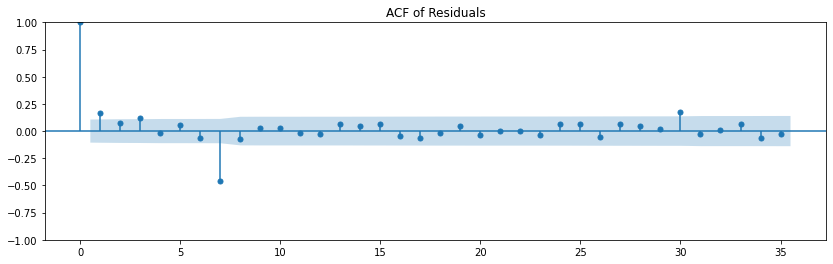

In [22]:
fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(residuals.dropna(), lags=35, ax=ax)
plt.title("ACF of Residuals")
plt.show()

The ACF plot of the residuals is used to check whether any autocorrelation remains after fitting the model.

Most of the autocorrelation values fall within the confidence interval, suggesting that the model has captured the majority of the temporal structure in the data.

However, there is a noticeable spike around lag 7, which indicates that some weekly seasonality may still not be fully captured by the model.

Overall, the residuals resemble white noise, but the presence of this spike suggests that further tuning of the seasonal component could improve the model.

## Step 13 — Forecast and evaluate

The model is used to forecast the test period.

Predictions are compared against actual sales using MAE, RMSE, and R².

In [23]:
# Generate predictions for the test set

predictions = model_fit.forecast(steps=len(test))

# Create comparison dataframe
comparison = pd.DataFrame({
    "actual": test["unit_sales"],
    "predicted": predictions
})

# Calculate error
comparison["error"] = comparison["actual"] - comparison["predicted"]

display(comparison.head())

,actual,predicted,error
2014-01-07,498.0,3.790537e+02,118.946286
2014-01-08,561.0,-1.449516e-17,561.000000
2014-01-09,239.0,5.890000e+02,-350.000000
2014-01-10,438.0,4.740000e+02,-36.000000
2014-01-11,619.0,7.670000e+02,-148.000000


In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(comparison["actual"], comparison["predicted"])
rmse = np.sqrt(mean_squared_error(comparison["actual"], comparison["predicted"]))
r2 = r2_score(comparison["actual"], comparison["predicted"])

print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 3))

MAE: 232.27
RMSE: 308.77
R²: -2.332


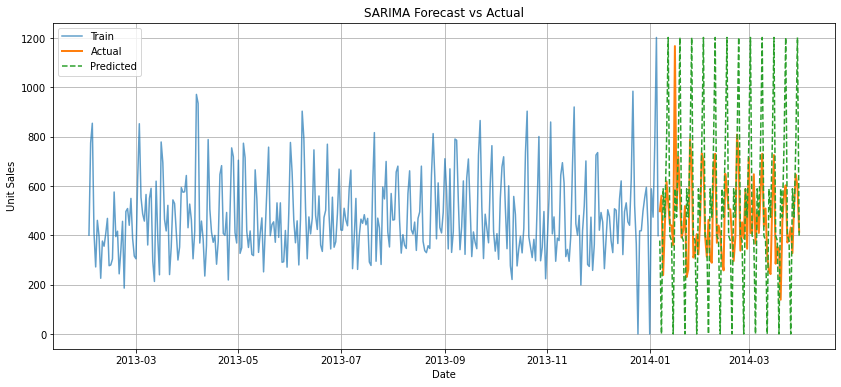

In [25]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train["unit_sales"], label="Train", alpha=0.7)
plt.plot(test.index, test["unit_sales"], label="Actual", linewidth=2)
plt.plot(test.index, predictions, label="Predicted", linestyle="--")

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Unit Sales")
plt.legend()
plt.grid(True)

plt.show()

The SARIMA model performs poorly, with a negative R² score (-2.33), indicating that it performs worse than a naive baseline.
This suggests that the model fails to capture the underlying structure of the data.

The main issue is that the model does not adequately capture the strong weekly seasonality present in the time series.
As discussed in the course, ARIMA-type models without proper seasonal components tend to revert to the mean and fail to track recurring patterns.

To address this, a full SARIMA model with seasonal AR and MA terms should be used.

## Step 14 — Try a small SARIMA grid search

The first SARIMA model is only a starting point.

To improve it, I test a small set of parameter combinations and compare them using AIC, MAE, and RMSE.

In [26]:
candidate_orders = [
    (1, 0, 0),
    (1, 1, 0),
    (1, 1, 1),
    (2, 1, 1),
]

candidate_seasonal_orders = [
    (0, 1, 0, 7),
    (1, 1, 0, 7),
    (0, 1, 1, 7),
    (1, 1, 1, 7),
]

results = []

for order in candidate_orders:
    for seasonal_order in candidate_seasonal_orders:
        try:
            model = SARIMAX(
                train["unit_sales"],
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fit = model.fit(disp=False)
            pred = fit.forecast(steps=len(test))

            mae = mean_absolute_error(test["unit_sales"], pred)
            rmse = np.sqrt(mean_squared_error(test["unit_sales"], pred))

            results.append({
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fit.aic,
                "MAE": mae,
                "RMSE": rmse
            })

        except Exception as e:
            print("Model failed:", order, seasonal_order, "|", e)

results_df = pd.DataFrame(results).sort_values("MAE")

display(results_df)

,order,seasonal_order,AIC,MAE,RMSE
2,"(1, 0, 0)","(0, 1, 1, 7)",4012.041050,96.979720,140.640431
3,"(1, 0, 0)","(1, 1, 1, 7)",4014.028081,97.114874,140.694506
14,"(2, 1, 1)","(0, 1, 1, 7)",4002.380148,99.772655,142.456937
10,"(1, 1, 1)","(0, 1, 1, 7)",4000.383195,99.796198,142.477520
15,"(2, 1, 1)","(1, 1, 1, 7)",4003.869432,100.303605,142.643529
11,"(1, 1, 1)","(1, 1, 1, 7)",4001.869811,100.310521,142.646845
1,"(1, 0, 0)","(1, 1, 0, 7)",4087.370684,189.662376,246.855366
13,"(2, 1, 1)","(1, 1, 0, 7)",4070.723985,194.280315,249.550209
9,"(1, 1, 1)","(1, 1, 0, 7)",4082.595816,194.649417,249.687187
6,"(1, 1, 0)","(0, 1, 1, 7)",4120.320859,223.007220,255.669032


The grid search shows that the best-performing model based on MAE is SARIMA(1, 0, 0)(0, 1, 1, 7).

This model clearly improves the forecast compared to the initial SARIMA setup. The MAE drops from 232.27 to 96.98, and the RMSE from 308.77 to 140.64, which is a significant improvement. This confirms that adding a seasonal moving average component (Q = 1) helps capture the weekly pattern in the data.

Some models achieve slightly lower AIC values, but they do not perform better on the test set. Since the goal here is forecasting, I prioritize MAE, as it reflects how well the model performs on unseen data.

It is also worth noting that increasing model complexity (higher p and q values) does not lead to better predictions. This suggests that the series does not require a highly complex structure, and that most of the signal can be explained by a simple autoregressive component combined with seasonal effects.

Overall, SARIMA(1, 0, 0)(0, 1, 1, 7) offers a good balance between performance and simplicity, and will be used as the final model.

## Step 15 — Train the best SARIMA model

The best model is selected based on the lowest MAE on the test period.

In [27]:
best_order = results_df.iloc[0]["order"]
best_seasonal_order = results_df.iloc[0]["seasonal_order"]

print("Best order:", best_order)
print("Best seasonal order:", best_seasonal_order)

best_model = SARIMAX(
    train["unit_sales"],
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fit = best_model.fit(disp=False)

best_predictions = best_fit.forecast(steps=len(test))

Best order: (1, 0, 0)
Best seasonal order: (0, 1, 1, 7)


In [28]:
best_comparison = pd.DataFrame({
    "actual": test["unit_sales"],
    "predicted": best_predictions
})

best_mae = mean_absolute_error(best_comparison["actual"], best_comparison["predicted"])
best_rmse = np.sqrt(mean_squared_error(best_comparison["actual"], best_comparison["predicted"]))
best_r2 = r2_score(best_comparison["actual"], best_comparison["predicted"])

print("Best SARIMA evaluation:")
print("MAE:", round(best_mae, 2))
print("RMSE:", round(best_rmse, 2))
print("R²:", round(best_r2, 4))

Best SARIMA evaluation:
MAE: 96.98
RMSE: 140.64
R²: 0.3088


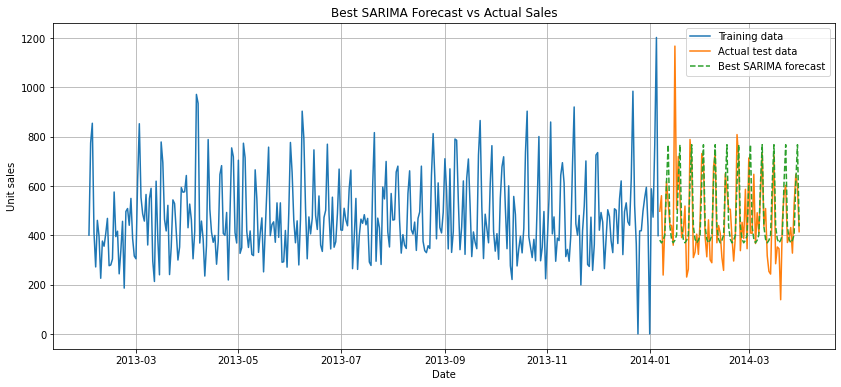

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train["unit_sales"], label="Training data")
plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, best_predictions, label="Best SARIMA forecast", linestyle="--")

plt.title("Best SARIMA Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The model clearly captures the weekly pattern, which can be seen in the repeated ups and downs in the forecast.

However, it does not capture the size of the peaks very well. When sales spike or drop suddenly, the model tends to smooth these movements and stay closer to the average.

This is expected with SARIMA models. They are good at learning regular patterns over time, but they struggle with sudden changes and high variability, which are common in retail sales data.

## Step 16 — Optional: SARIMAX with external variables

SARIMAX can include external variables such as oil prices and holiday indicators.

These variables should only be used if they are available at prediction time. In this notebook, they are tested as possible explanatory features.

In [31]:

exog_cols = [
    "dcoilwtico",
    "is_holiday",
    "is_national_holiday",
    "is_regional_holiday",
    "is_local_holiday",
    "is_weekend",
    "is_month_start",
    "is_month_end"
]

df_model = df.set_index("date").asfreq("D")


train_exog = df_model.loc[train.index, exog_cols]
test_exog = df_model.loc[test.index, exog_cols]

train_exog = train_exog.fillna(method="ffill")
test_exog = test_exog.fillna(method="ffill")


print("External features used:")
print(exog_cols)

print("\nMissing values in train_exog:")
print(train_exog.isna().sum())

print("\nMissing values in test_exog:")
print(test_exog.isna().sum())

External features used:
['dcoilwtico', 'is_holiday', 'is_national_holiday', 'is_regional_holiday', 'is_local_holiday', 'is_weekend', 'is_month_start', 'is_month_end']

Missing values in train_exog:
dcoilwtico             0
is_holiday             0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
is_weekend             0
is_month_start         0
is_month_end           0
dtype: int64

Missing values in test_exog:
dcoilwtico             0
is_holiday             0
is_national_holiday    0
is_regional_holiday    0
is_local_holiday       0
is_weekend             0
is_month_start         0
is_month_end           0
dtype: int64


In [33]:
sarimax_model = SARIMAX(
    train["unit_sales"],
    exog=train_exog,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

sarimax_predictions = sarimax_fit.forecast(
    steps=len(test),
    exog=test_exog
)

In [34]:
sarimax_mae = mean_absolute_error(test["unit_sales"], sarimax_predictions)
sarimax_rmse = np.sqrt(mean_squared_error(test["unit_sales"], sarimax_predictions))
sarimax_r2 = r2_score(test["unit_sales"], sarimax_predictions)

print("SARIMAX with external features:")
print("MAE:", round(sarimax_mae, 2))
print("RMSE:", round(sarimax_rmse, 2))
print("R²:", round(sarimax_r2, 4))

SARIMAX with external features:
MAE: 96.58
RMSE: 139.85
R²: 0.3165


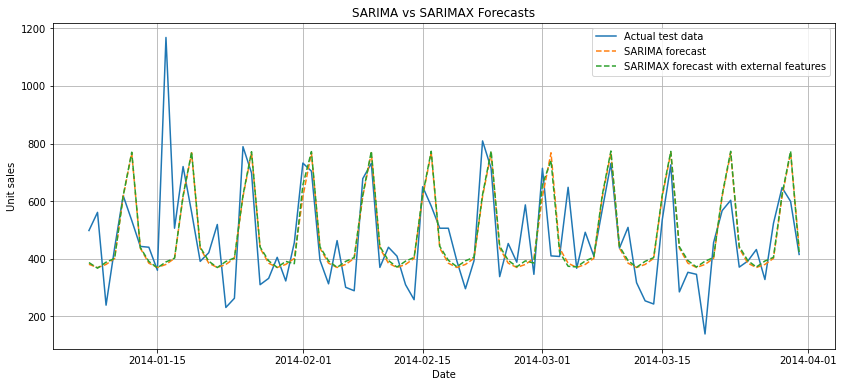

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test["unit_sales"], label="Actual test data")
plt.plot(test.index, best_predictions, label="SARIMA forecast", linestyle="--")
plt.plot(test.index, sarimax_predictions, label="SARIMAX forecast with external features", linestyle="--")

plt.title("SARIMA vs SARIMAX Forecasts")
plt.xlabel("Date")
plt.ylabel("Unit sales")
plt.legend()
plt.grid(True)
plt.show()

The SARIMA and SARIMAX forecasts look very similar, and both models capture the weekly pattern quite well.

Adding external variables leads to a small improvement. In some cases, SARIMAX is slightly closer to the real values, but the difference is not very noticeable overall.

Both models still produce quite smooth predictions, while the actual sales show sharp spikes and sudden drops. So even though the general pattern is captured, the models struggle to follow the more irregular behavior in the data.

In this case, the external features don’t add much. The main limitation comes from the model itself, which is not able to capture more complex or non-linear patterns in the series.

## Summary

In this notebook, I built and evaluated classical time series models to forecast daily `unit_sales`.

I started by exploring the data, visualizing the series, and decomposing it into trend, seasonality, and residuals. I also checked for stationarity using the ADF test and used ACF and PACF plots to guide the choice of model parameters.

A SARIMA model with weekly seasonality was used as a baseline. It was able to capture the general pattern of the data, especially the weekly cycle, but struggled with sudden spikes and drops in sales.

I then extended the model to SARIMAX by including external variables such as oil prices and calendar-based features. This led to a small improvement, but the overall behavior of the model remained very similar.

Overall, the results show that classical time series models can capture the main structure of the data, but have limitations when it comes to handling high variability and irregular patterns.

The next step is to compare these results with machine learning models such as XGBoost, which can better leverage the engineered features and capture more complex relationships.